# Task 1 — Data Loading & Exploration


In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("Housing.csv")
data=df.copy()
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
data.shape
#545 rows and 13 cols

(545, 13)

In [5]:
# Target
y = data["price"]

# Features
X = data.drop("price", axis=1)

In [6]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# TASK 2. DATA CLEANING

In [8]:
#no null values in any of the column
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
data.duplicated()
data.drop_duplicates(inplace=True)
#No duplicated rows present

In [10]:
yes_no_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning", "prefarea"
]

for col in yes_no_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [11]:
from sklearn.preprocessing import OneHotEncoder

In [12]:
encoder = OneHotEncoder(sparse_output=False, drop="first")

encoded = encoder.fit_transform(df[["furnishingstatus"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["furnishingstatus"])
)
df = pd.concat(
    [df.drop("furnishingstatus", axis=1), encoded_df],
    axis=1
)

## Features Engineering

In [13]:
df["price_per_sqft"]=df["price"]/df["area"]
df["rooms"]=df["bedrooms"]+df["bathrooms"]
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price_per_sqft,rooms
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0,1792.452830,6
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0,1367.187500,8
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0,0.0,1229.919679,5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0.0,0.0,1628.666667,6
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0.0,0.0,1537.735849,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0,1.0,606.666667,3
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1.0,0.0,736.312500,4
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0,1.0,483.425414,3
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0.0,0.0,601.374570,4


# Task 3 — Model Building


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [19]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("LR:", mae_lr, rmse_lr, r2_lr)

LR: 504031.7775311067 766300.9143587594 0.8838245265717732


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [21]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("LR:", mae_lr, rmse_lr, r2_lr)
print("RF:", mae_rf, rmse_rf, r2_rf)

LR: 504031.7775311067 766300.9143587594 0.8838245265717732
RF: 284207.32752293575 573974.2767599064 0.9348220611595373


# Task 4 — Visualization

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

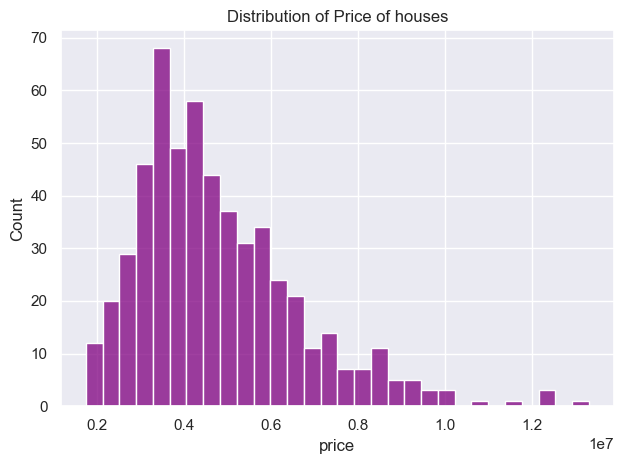

In [82]:
fig, ax=plt.subplots()
sns.set_theme(style="darkgrid")
sns.histplot(
    data=df,
    x="price",
    bins=30,
    color="purple",
    ax=ax
)
ax.set_title("Distribution of Price of houses")
plt.savefig("charts/histplot")
fig.tight_layout()

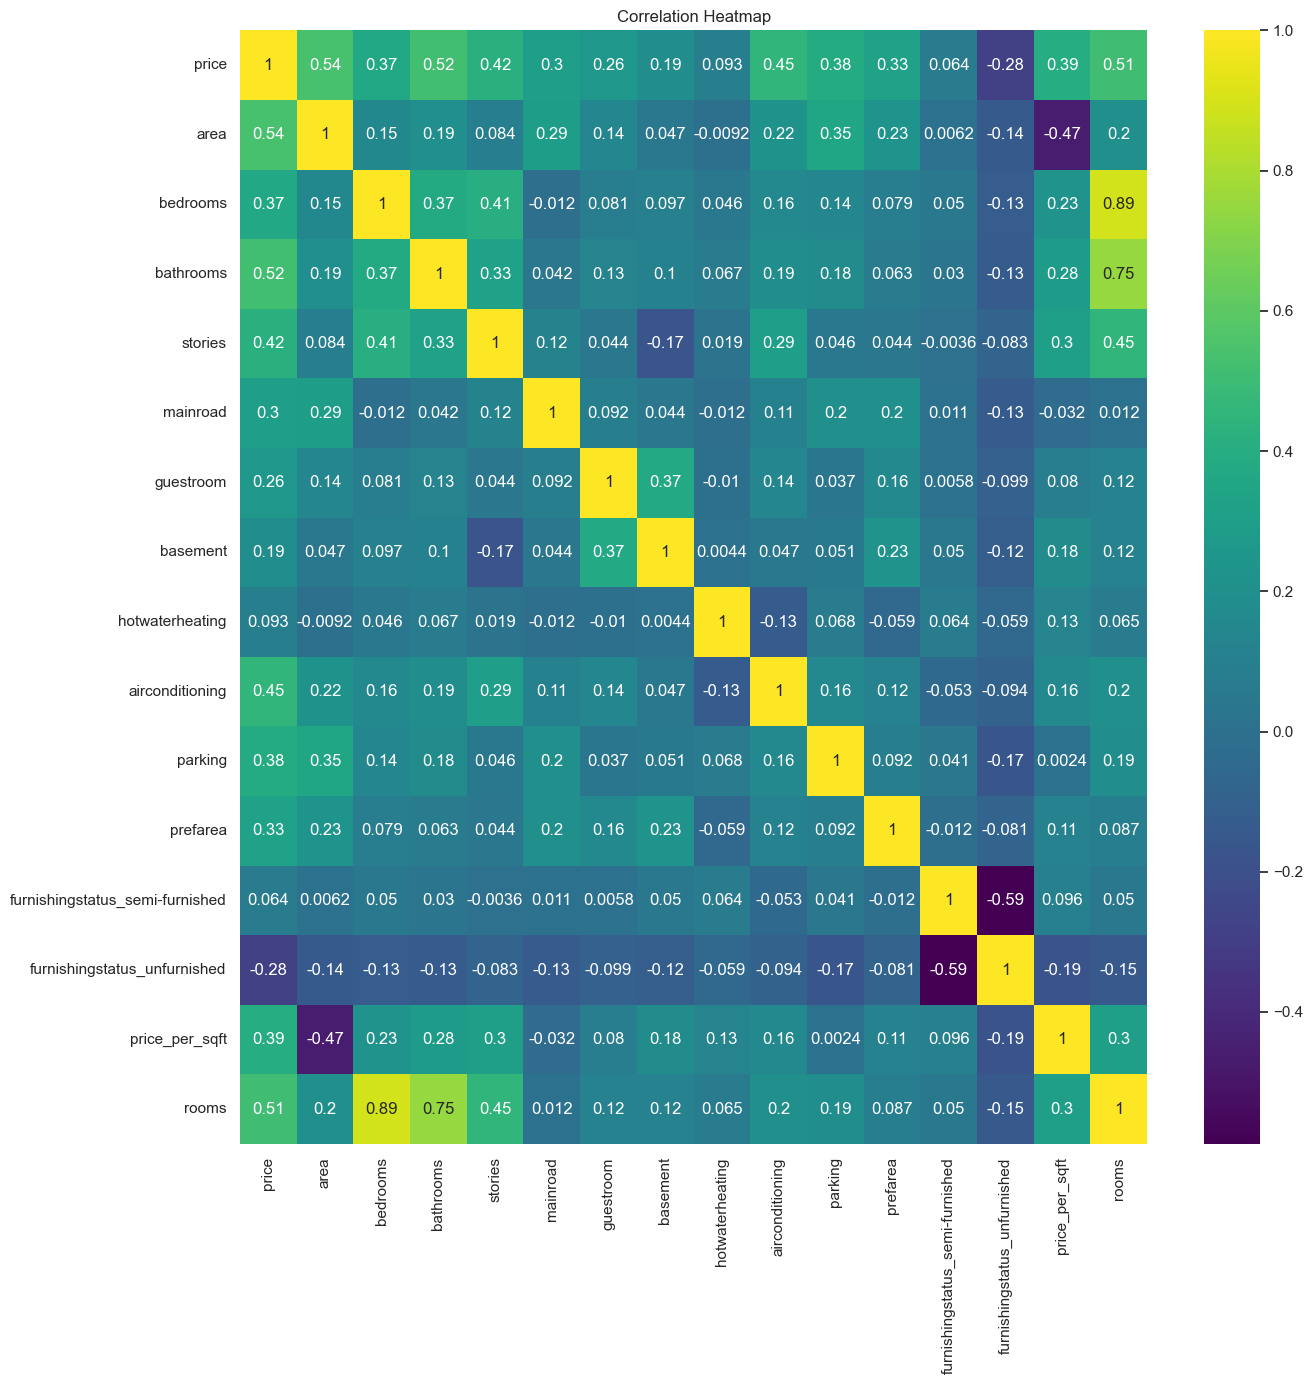

In [83]:
#for creating correlation matrix
corr=df.corr()
fig, ax=plt.subplots(figsize=(14,14))
sns.set_theme(style="darkgrid")
sns.heatmap(
    corr,
    cmap="viridis",
    annot=True,
    ax=ax
)
ax.set_title("Correlation Heatmap")
plt.savefig("charts/correlationHeatmap")
fig.tight_layout()

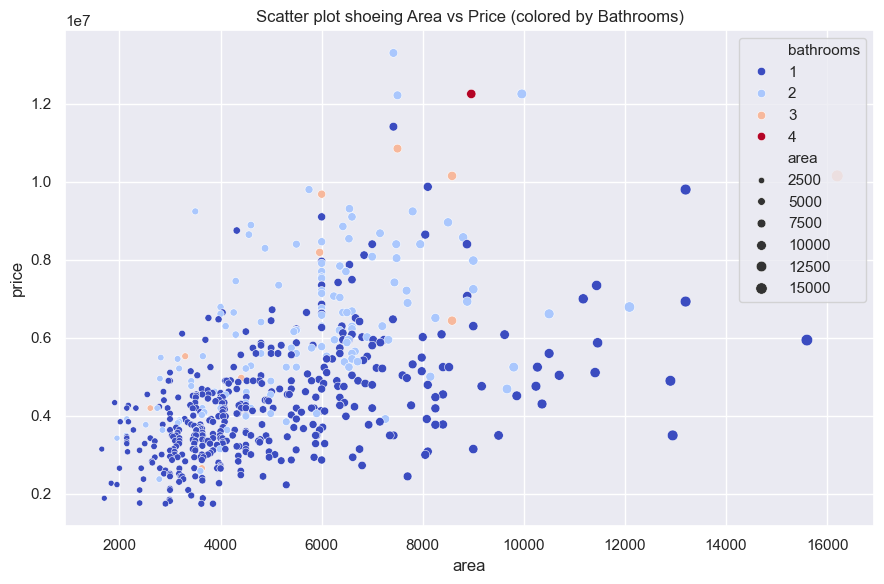

In [88]:
fig, ax=plt.subplots(figsize=(9,6))
sns.set_theme(style="darkgrid")
sns.scatterplot(
   data=df,
    x="area",
    y="price",
    hue="bathrooms",
    size="area",
    palette="coolwarm",
    ax=ax
)
ax.set_title("Scatter plot shoeing Area vs Price (colored by Bathrooms)")
plt.savefig("charts/scatterplot")
fig.tight_layout()

# Task 5 — Insights & Summary

### The most important features influencing house price were area, number of bathrooms,number of rooms, air conditioning, and preferred area location  as seen in the correlation heatmap.
### Also the unfurnished feature has a negative correlation with price, meaning that as the likelihood of a house being unfurnished increases, its price tends to decrease.

### The Random Forest model performed better than Linear Regression, showing lower error values and a higher R² score, meaning it captured complex relationships better than LR.
### The model predictions were fairly accurate, especially for mid-range houses, though some extreme values were harder to predict.

### One interesting observation was that amenities like air conditioning and furnishing status had a noticeable impact on price, not just size.
### A key recommendation for real estate businesses is to focus on enhancing property features like furnishing and amenities, as they significantly increase property value along with location.